### `socket`
Le socket sono meccanismi che il sistema operativo offre ai processi per l'accesso alla rete. Una socket è caratterizzata da due elementi:
- ip
- porta

e può essere di due tipi (TCP, UDP)

L'implementazione in Python è offerta dal modulo `socket`. Dalla documentazione ufficiale:

> This module provides access to the BSD *socket* interface. It is available on all modern Unix systems, Windows, MacOS, and probably additional platforms.

> The Python interface is a straightforward transliteration of the Unix system call and library interface for sockets to Python’s object-oriented style: the function returns a *socket object* whose methods implement the various socket system calls. Parameter types are somewhat higher-level than in the C interface: as with `read()` and `write()` operations on Python files, buffer allocation on receive operations is automatic, and buffer length is implicit on send operations.

È possibile creare una socket con *`socket.socket(socket_family, socket_type)`*, dove `socket_family` indica IPv4, IPv6, ... e `socket_type` è TCP / UDP

In particolare:
- `socket_family` : `AF_INET` (IPv4), `AF_INET6` (IPv6)
- `socket_type`: `SOCK_STREAM` per TCP, `SOCK_DGRM` per UDP

#### Le principali funzioni
Le principali funzioni (generali) di `socket` sono:

In [ ]:
from socket import socket as s

help(s.bind) # <--  Anche se realisticamente solo un server usa `bind()`
help(s.close)

##### TCP

In [ ]:
from socket import socket as s

help(s.send)
help(s.recv)

Funzioni del server:

In [ ]:
from socket import socket as s

help(s.listen)
help(s.accept)

Funzioni del client:

In [ ]:
from socket import socket as s

help(s.connect)

##### UDP

In [ ]:
from socket import socket as s

help(s.sendto)
help(s.recvfrom) # <-- Nota che `recvfrom` ritorna il messaggio + `addr` del mittente

Ecco una tabella di **recap**:

| Funzione | Bloccante | Contesto | Descrizione |
| :--- | :--- | :--- | :--- |
| `socket()` | No | Comune | Costruttore del socket |
| `bind(addr)` | No | Comune (Server) | Lega il socket all'indirizzo (host, port) |
| `close()` | No | Comune | Chiude il socket e libera le risorse |
| `connect(addr)`| **Sì** | TCP Client | Apre una connessione verso il server |
| `listen(n)` | No | TCP Server | Mette il socket in ascolto (modalità TCP) |
| `accept()` | **Sì** | TCP Server | Accetta una connessione (ritorna nuovo socket) |
| `send(item)` | **Sì*** | TCP | Invia dati su una connessione stabilita |
| `recv(buf)` | **Sì** | TCP | Riceve dati da una connessione stabilita |
| `sendto(i, a)` | **Sì*** | UDP | Invia dati a un indirizzo specifico |
| `recvfrom(buf)`| **Sì** | UDP | Riceve dati e restituisce indirizzo mittente |

*\*Invia i dati ai buffer di sistema; blocca l'esecuzione solo se il buffer è completamente pieno.*

**Implementaione client-server TCP:**
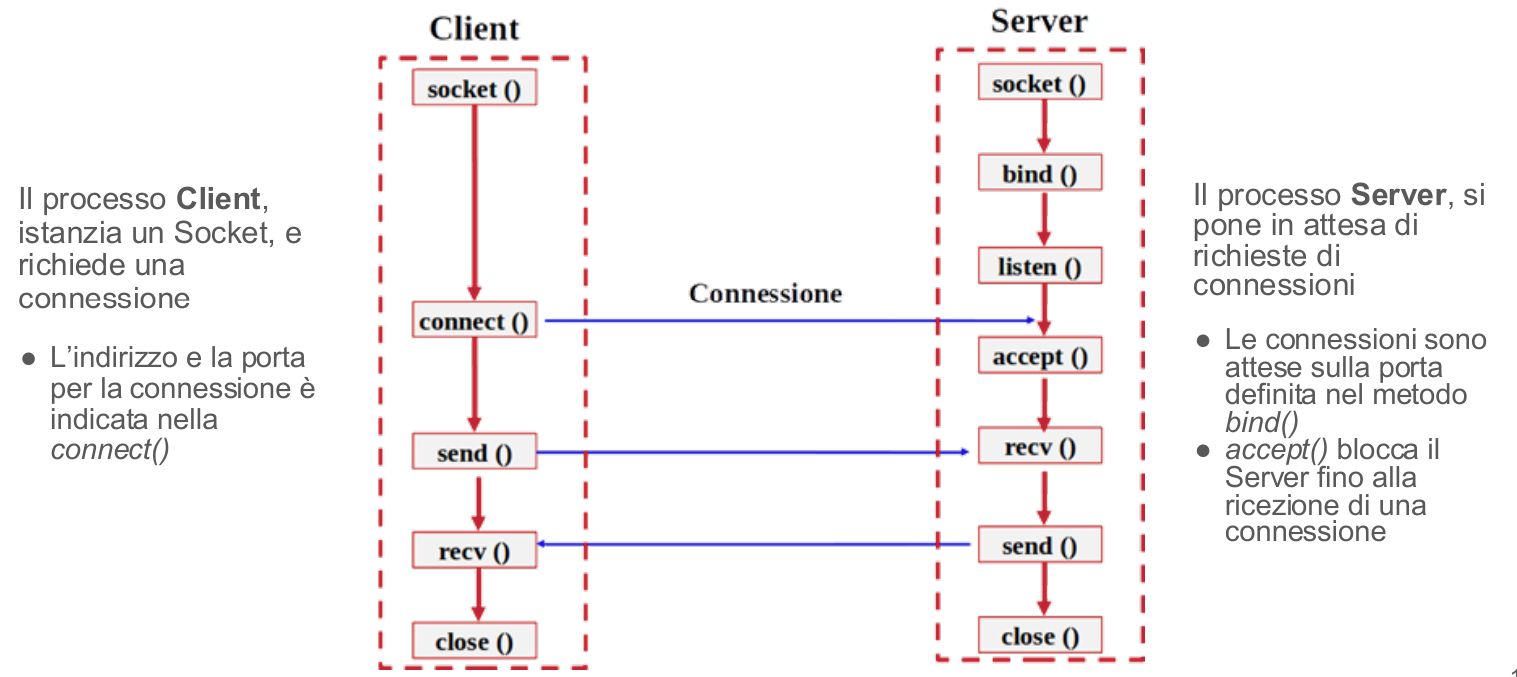 

Per un ***esempio*** (file di riferimento `client_tcp.py` e `server_tcp.py`) esegui la cella qui sotto per avviare il server; vedrai un output del tipo:

```
INFO SERVER_TCP In ascolto su 0.0.0.0:{porta}
```
apri il terminale nella repo e lancia:

```bash
uv run python notebooks/02_networking/python/client_tcp.py --port {porta} --message {messaggio che vuoi!}
```

In [ ]:
!uv run python server_tcp.py --port 0 --backlog 1 --timeout 30

> **Nota**: passare `0` come porta al server (`--port 0`) non significa che aprirà la connessione sulla porta `0`, ma che la aprirà sulla prima disponibile (fornita dal SO). Infatti, il server controlla quale porta gli è stata assegnata con `s.getsockname()[1]`. In particolare, si fa *getsockname()**[1]*** perché per IPv4 il metodo ritorna la tupla `(hostaddr, port)`. Maggior dettagli qui:

In [ ]:
from socket import socket as s

help(s.getsockname)

**Implementazione client-server UDP**:
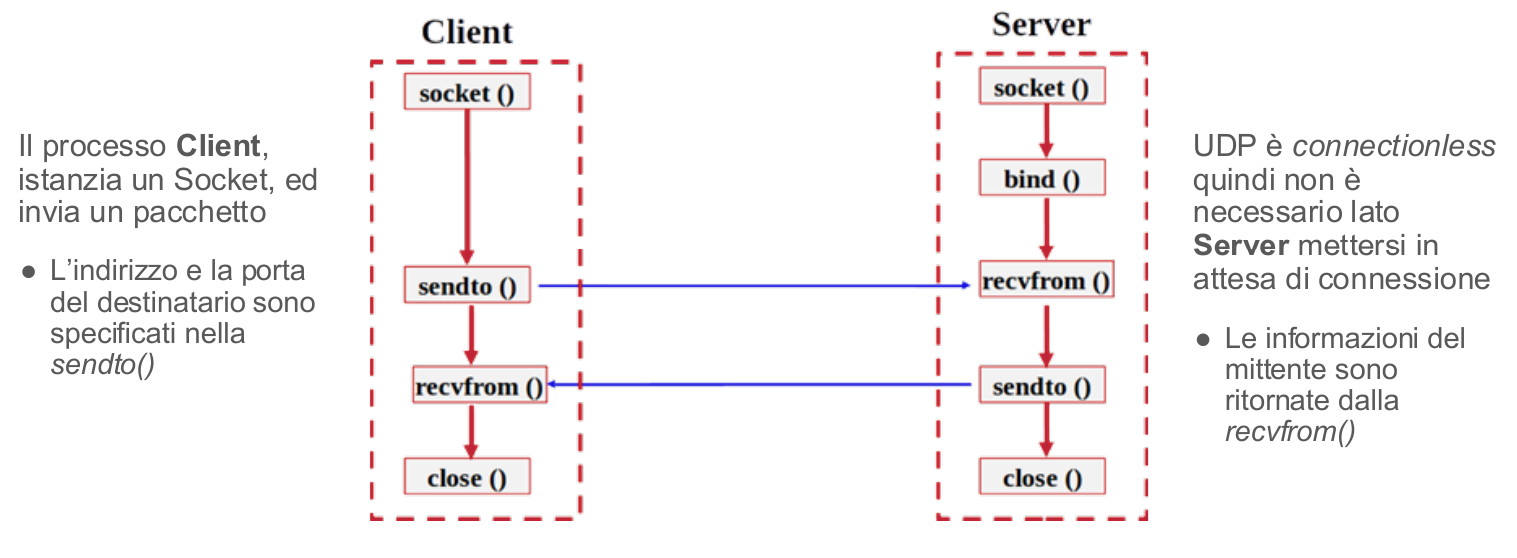

Per un ***esempio*** (file di riferimento `client_udp.py` e `server_udp.py`) esegui la cella qui sotto per avviare il server; vedrai un output del tipo:

```
INFO SERVER_UDP In ascolto su 0.0.0.0:{porta}
```
apri il terminale nella repo e lancia:

```bash
uv run python notebooks/02_networking/python/client_udp.py --port {porta} --message {messaggio che vuoi!}
```

In [ ]:
!uv run python server_udp.py --port 0 --timeout 30

**Si noti l'utilizzo nei file di `s.settimeout(...)`, il cui scopo è quello di definire un tempo massimo di attesa per le operazioni bloccanti.**

```python
...
s.settimeout(time_left)
...
try:
    conn, addr = accept()
except socket.timeout: # <-- Alias di TimeoutError
    logger.info("Timeout")
```

In [ ]:
from socket import socket as s
help(s.settimeout)

---

#### Multithreading e multiprocessing

In questo contesto, **multithreading** e **multiprocessing** migliorano l'efficienza dei server per gestire più richieste.


> Ad esempio, si pensi a un server TCP che per ogni connessione accettata avvia un thread / processo dedicato

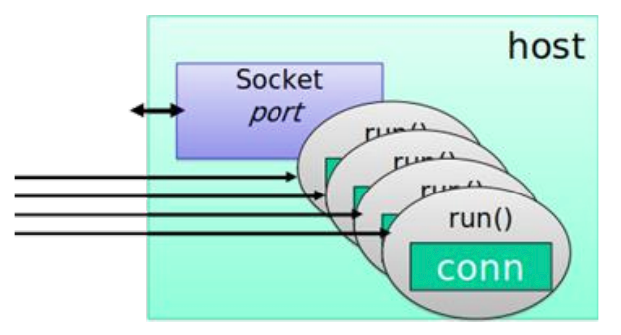

In tal caso, i *Thread/Process devono prevedere un costruttore che accetti come parametro/i*:
- **TCP**: una connessione (restituita dal metodo accept); tutte le connessioni sono gestite da un thread/process differente

- **UDP**: l’indirizzo/porta del mittente ed il messaggio ricevuto (restituito dal metodo recvfrom); ogni richiesta è gestita da un thread/process differente

**Ad esempio**, prova a lanciare la cella qui sotto (oppure con `server_tcp_multiprocess.py`) e come visto prima, da terminale lancia vari client

In [ ]:
!uv run python server_tcp_multithread.py --port 0 --backlog 2 --timeout 40